In [1]:
import uproot
import os
import cats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit

In [2]:
#07200728_0905/07200730_1044
amps=[]
chisq=[]
series_list=["07200728_0905"]
for s in series_list:
    for fname in os.listdir("/projects/standard/yanliusp/shared/data/UMN_K100/"+s+"/"):
        with uproot.open("/projects/standard/yanliusp/shared/data/UMN_K100/"+s+"/"+fname) as f:
            amps+=list(np.array(f["rqDir/zip1"]["PTOFamps"]))
            chisq+=list(np.array(f["rqDir/zip1"]["PTOFchisq"]))

In [3]:
np.array(f["rqDir/zip1/PFOFamps"])

array([ 1.34295174e-07,  3.97944697e-08,  9.05783707e-07,  1.65393025e-07,
        5.81905131e-07,  4.03992628e-08,  1.29081610e-10,  4.00619694e-08,
        2.52299703e-07, -4.93060815e-08,  1.29390924e-06,  3.87911016e-08,
        3.85659416e-07,  7.26714263e-10,  1.07999640e-07,  9.49887576e-08,
        4.35625918e-10,  4.11397658e-07,  6.47313510e-07,  5.92150177e-08,
        5.38506305e-08,  2.81354267e-08,  1.98159639e-07,  2.65574154e-08,
        9.61100461e-08,  7.71170073e-11,  6.00275520e-08,  6.91637012e-08,
        1.10691936e-07,  1.05471133e-07,  3.76684216e-07,  2.49500836e-07,
        1.89681042e-08,  3.38069243e-07,  5.11164440e-08,  5.40131081e-08,
        7.30954506e-10,  7.80872720e-08,  9.46907153e-08,  2.18868328e-07,
        1.25412476e-07,  1.18958953e-07,  8.26844453e-08,  2.67607658e-07,
        2.61511879e-07,  2.74958215e-08,  8.35915333e-08,  8.24883473e-08,
        3.65445234e-08,  6.15377859e-08,  3.82305441e-08,  4.43297878e-08,
        3.11540400e-07,  

In [9]:
amps=np.array(amps)
chisq=np.array(chisq)

/tmp/ipykernel_3182748/1705093535.py:2: RuntimeWarning: invalid value encountered in log10
  h=ax.hist2d(np.log10(amps),np.log10(chisq),bins=(np.linspace(-12,-5,500),np.linspace(3.5,8,500)),norm="log",cmap="viridis")


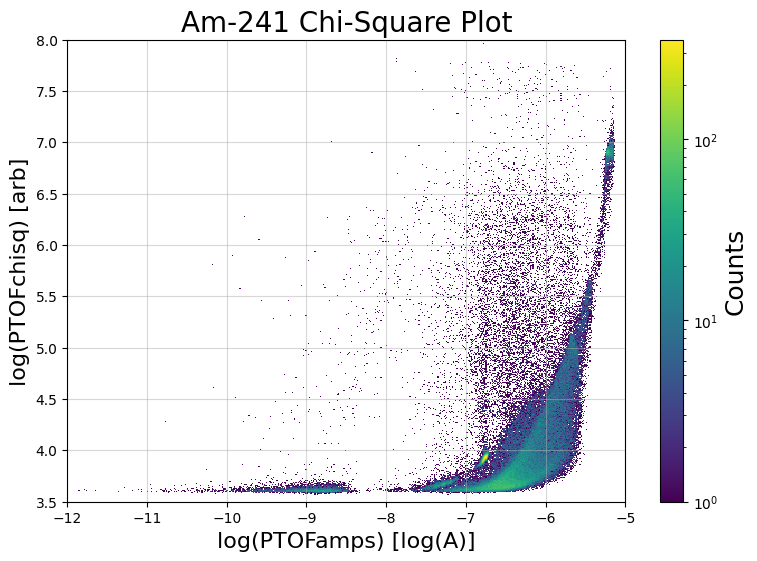

In [10]:
fig,ax=plt.subplots(figsize=(9,6))
h=ax.hist2d(np.log10(amps),np.log10(chisq),bins=(np.linspace(-12,-5,500),np.linspace(3.5,8,500)),norm="log",cmap="viridis")
ax.grid(alpha=0.5)
c=fig.colorbar(h[3],ax=ax)
c.set_label("Counts",fontsize=18)
plt.xlabel("log(PTOFamps) [log(A)]",fontsize=16)
plt.ylabel("log(PTOFchisq) [arb]",fontsize=16)
plt.title("Am-241 Chi-Square Plot",fontsize=20)
plt.show()

/tmp/ipykernel_3182748/3346876869.py:2: RuntimeWarning: invalid value encountered in log10
  h=ax.hist2d(np.log10(amps),np.log10(chisq),


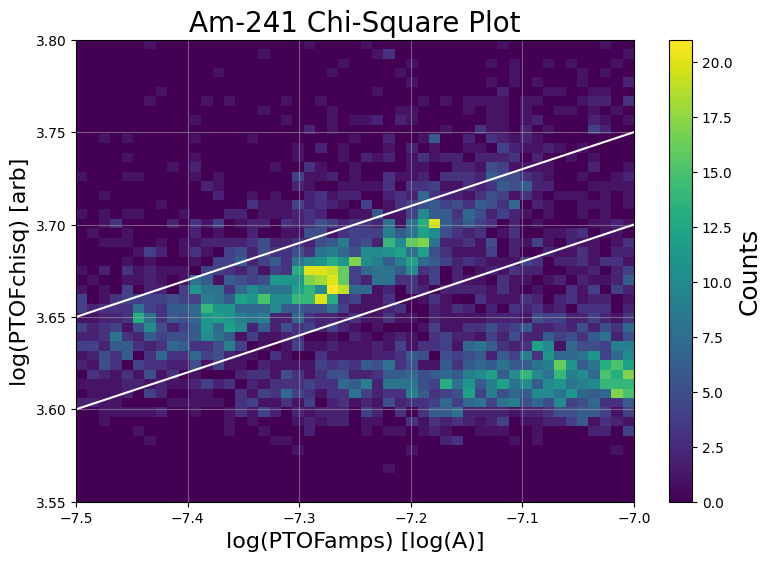

In [6]:
fig,ax=plt.subplots(figsize=(9,6))
h=ax.hist2d(np.log10(amps),np.log10(chisq),
            bins=(np.linspace(-7.5,-7,50),np.linspace(3.55,3.8,50)),cmap="viridis")
plt.plot([-7.5,-7],[3.6,3.7],c="w")
plt.plot([-7.5,-7],[3.65,3.75],c="w")
ax.grid(alpha=0.5)
c=fig.colorbar(h[3],ax=ax)
c.set_label("Counts",fontsize=18)
plt.xlabel("log(PTOFamps) [log(A)]",fontsize=16)
plt.ylabel("log(PTOFchisq) [arb]",fontsize=16)
plt.title("Am-241 Chi-Square Plot",fontsize=20)
plt.show()

/tmp/ipykernel_3182748/1518703659.py:1: RuntimeWarning: invalid value encountered in log10
  cut_10=((np.log10(chisq)-3.6)/0.1>(np.log10(amps)+7.5)/0.5)&\
/tmp/ipykernel_3182748/1518703659.py:2: RuntimeWarning: invalid value encountered in log10
  ((np.log10(chisq)-3.65)/0.1<(np.log10(amps)+7.5)/0.5)&\


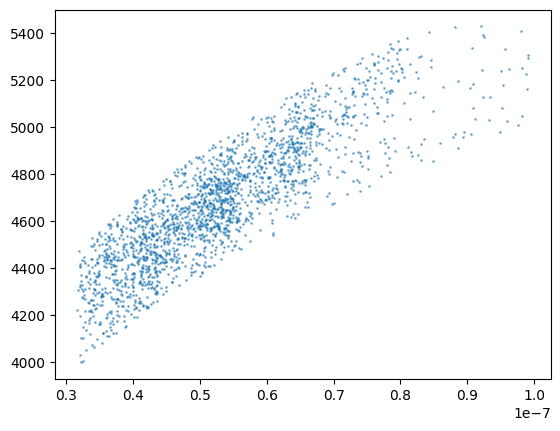

In [7]:
cut_10=((np.log10(chisq)-3.6)/0.1>(np.log10(amps)+7.5)/0.5)&\
       ((np.log10(chisq)-3.65)/0.1<(np.log10(amps)+7.5)/0.5)&\
       (amps>10**-7.5)&(amps<1e-7)
plt.scatter(amps[cut_10],chisq[cut_10],s=1,alpha=0.5)
plt.show()

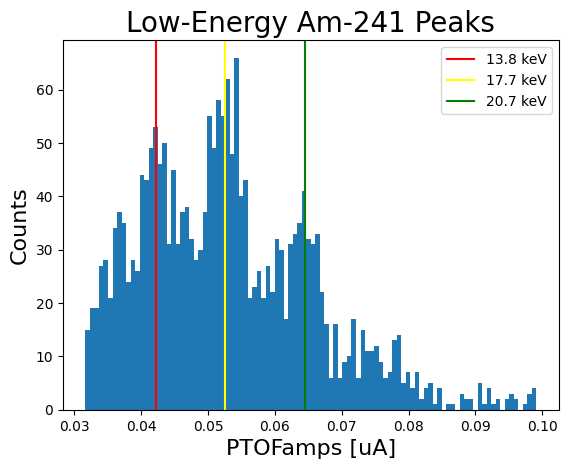

In [11]:
plt.hist(1e6*amps[cut_10],bins=100)
plt.axvline(0.4225e-1,c="red",label="13.8 keV")
#plt.axvline(0.475e-1,c="red")
plt.axvline(0.525e-1,c="yellow",label="17.7 keV")
#plt.axvline(0.57e-1,c="orange")
plt.axvline(0.645e-1,c="green",label="20.7 keV")
#plt.axvline(0.815e-1,c="green",label="26.3 keV")
plt.legend()
plt.title("Low-Energy Am-241 Peaks",fontsize=20)
plt.xlabel("PTOFamps [uA]",fontsize=16)
plt.ylabel("Counts",fontsize=16)
plt.show()
peak_138=0.4225e-7#np.mean(amps[cut_10][(amps[cut_10]>0.39e-7)&(amps[cut_10]<0.475e-7)])
peak_177=0.525e-7#np.mean(amps[cut_10][(amps[cut_10]>0.475-7)&(amps[cut_10]<0.57e-7)])
peak_207=0.645e-7

/tmp/ipykernel_821166/686312078.py:2: RuntimeWarning: invalid value encountered in log10
  h=ax.hist2d(np.log10(amps),np.log10(chisq),bins=(np.linspace(-6.85,-6.7,100),np.linspace(3.8,4.,100)),cmap="viridis")


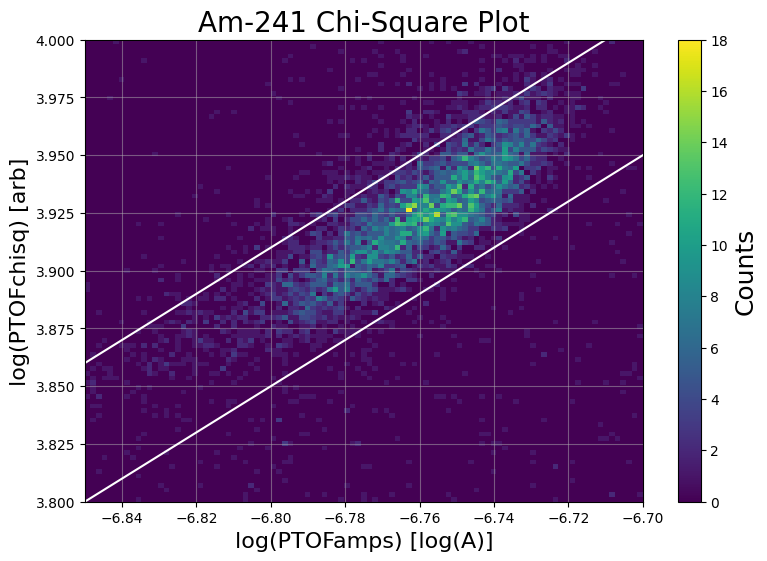

In [9]:
fig,ax=plt.subplots(figsize=(9,6))
h=ax.hist2d(np.log10(amps),np.log10(chisq),bins=(np.linspace(-6.85,-6.7,100),np.linspace(3.8,4.,100)),cmap="viridis")
plt.plot([-6.85,-6.7],[3.8,3.95],c="w")
plt.plot([-6.85,-6.7],[3.86,4.01],c="w")
ax.grid(alpha=0.5)
c=fig.colorbar(h[3],ax=ax)
c.set_label("Counts",fontsize=18)
plt.xlabel("log(PTOFamps) [log(A)]",fontsize=16)
plt.ylabel("log(PTOFchisq) [arb]",fontsize=16)
plt.title("Am-241 Chi-Square Plot",fontsize=20)
plt.show()

/tmp/ipykernel_3182748/3224477972.py:1: RuntimeWarning: invalid value encountered in log10
  cut_60=((np.log10(chisq)-3.8)/0.15>(np.log10(amps)+6.85)/0.15)&((np.log10(chisq)-3.86)/0.15<(np.log10(amps)+6.85)/0.15)&(amps>10**-6.94)&(amps<10**-6.65)


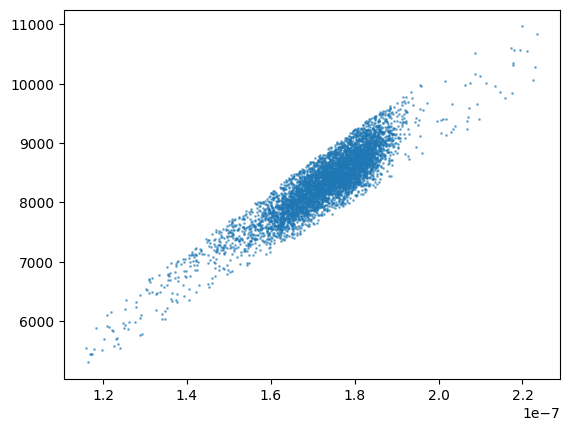

In [13]:
cut_60=((np.log10(chisq)-3.8)/0.15>(np.log10(amps)+6.85)/0.15)&((np.log10(chisq)-3.86)/0.15<(np.log10(amps)+6.85)/0.15)&(amps>10**-6.94)&(amps<10**-6.65)
plt.scatter(amps[cut_60],chisq[cut_60],s=1,alpha=0.5)
plt.show()

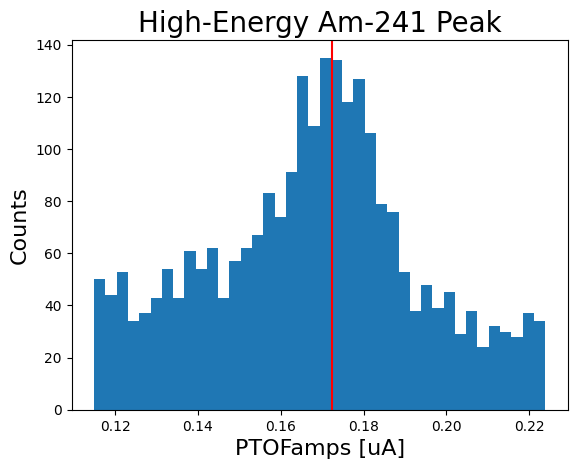

In [59]:
peak_60=0.1725e-6#np.mean(amps[cut_60])
plt.hist(1e6*amps[cut_60],bins=40)
plt.axvline(peak_60*1e6,c="r")
plt.title("High-Energy Am-241 Peak",fontsize=20)
plt.xlabel("PTOFamps [uA]",fontsize=16)
plt.ylabel("Counts",fontsize=16)
plt.show()

In [57]:
def saturation(A,k,a):
    return k*(np.exp(A/a)-1)
k,a=tuple(curve_fit(saturation,[peak_138*1e6,peak_177*1e6,peak_207*1e6,peak_60*1e6],[13.8,17.7,20.7,60])[0])

In [65]:
np.sqrt(curve_fit(saturation,[peak_138*1e6,peak_177*1e6,peak_207*1e6,peak_60*1e6],[13.8,17.7,20.7,60])[1])

array([[108.82106832,   5.87539394],
       [  5.87539394,   0.31730319]])

In [66]:
k,a

(np.float64(317.0352871690767), np.float64(0.9955280703541577))

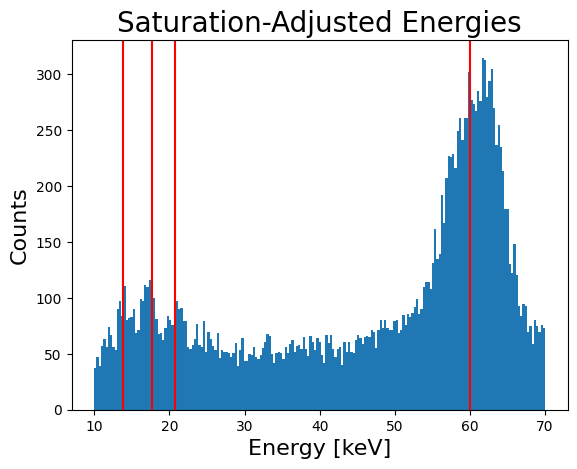

In [73]:
plt.hist(k*(np.exp(amps*1e6/a)-1),bins=np.linspace(10,70,200))
plt.axvline(13.8,c="r")
plt.axvline(17.7,c="r")
plt.axvline(20.7,c="r")
plt.axvline(60,c="r")
plt.title("Saturation-Adjusted Energies",fontsize=20)
plt.xlabel("Energy [keV]",fontsize=16)
plt.ylabel("Counts",fontsize=16)
plt.show()

In [13]:
peak_60

np.float64(1.714984950051132e-07)

In [14]:
(17.7/peak_177)/(13.8/peak_138),(20.7/peak_207)/(13.8/peak_138),(59.5/peak_60)/(13.8/peak_138),

(1.0321946169772256, 0.9825581395348836, np.float64(1.0621950651347263))

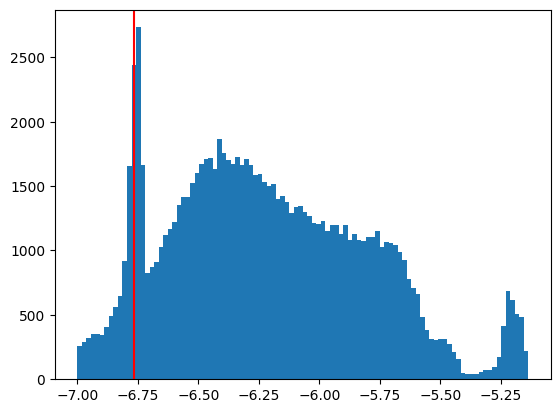

In [15]:
plt.hist(np.log10(amps[amps>1e-7]),bins=100)
plt.axvline(np.log10(peak_60),c="r")
plt.show()

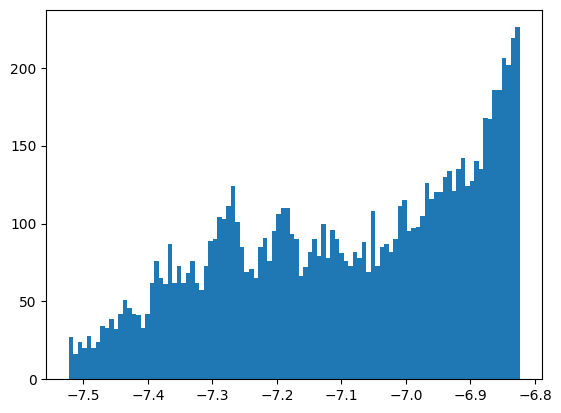

In [55]:
plt.hist(np.log10(amps[(amps<1.5e-7)&(amps>3e-8)]),bins=100)
plt.show()

In [ ]:
#/data/chocula/mast/myProcessedData/midasrq/byseries
#/data/chocula/fritts/data/k100proc/midasrq/byseries

In [20]:
np.array(f["rqDir/eventTree/EventType"])

array([65535., 65535., 65535., ..., 65535., 65535., 65535.], shape=(2107,))